#### Face Noise Protection with StyleGAN Noise

In [1]:
!pip install opencv-contrib-python

  Using cached opencv_contrib_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_contrib_python-4.11.0.86-cp37-abi3-win_amd64.whl (46.2 MB)


In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_korean_font():
    """한글 폰트 자동 설정"""
    font_candidates = ["NanumGothic", "Malgun Gothic", "AppleGothic"]  # Windows, Mac, Linux 폰트
    font_found = False

    for font in fm.findSystemFonts():
        font_name = fm.FontProperties(fname=font).get_name()
        if font_name in font_candidates:
            plt.rc("font", family=font_name)
            font_found = True
            print(f"✅ 한글 폰트 적용: {font_name}")
            break

    if not font_found:
        print("⚠️ 한글 폰트를 찾을 수 없습니다. 기본 폰트 사용.")

# 한글 폰트 설정 실행
set_korean_font()

✅ 한글 폰트 적용: NanumGothic


이미지 변환 및 저장 진행: 100%|██████████| 21/21 [00:56<00:00,  2.70s/it]


이미지 출력 중...


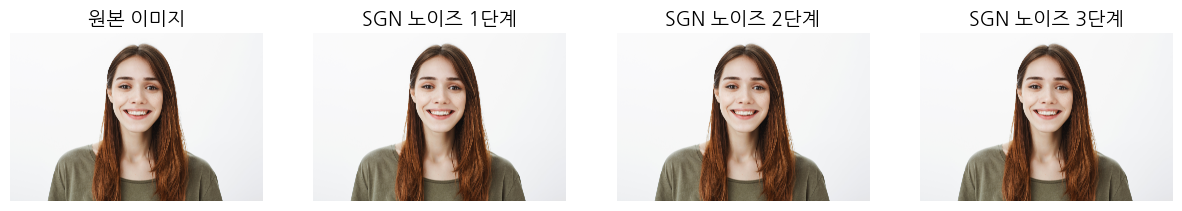

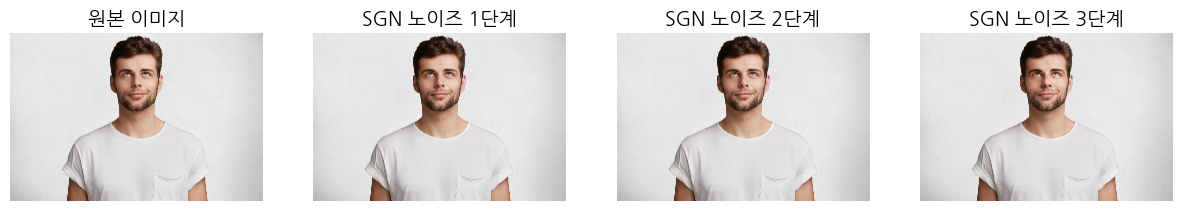

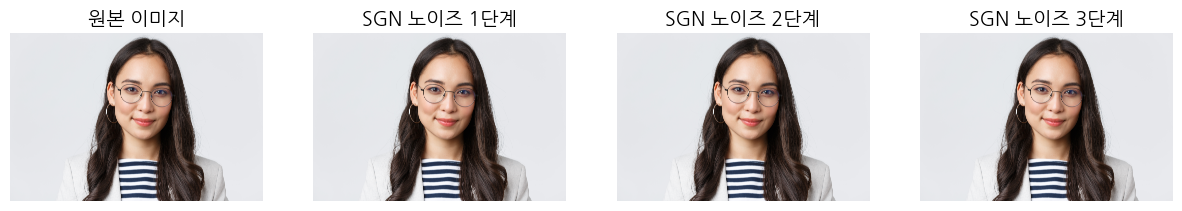

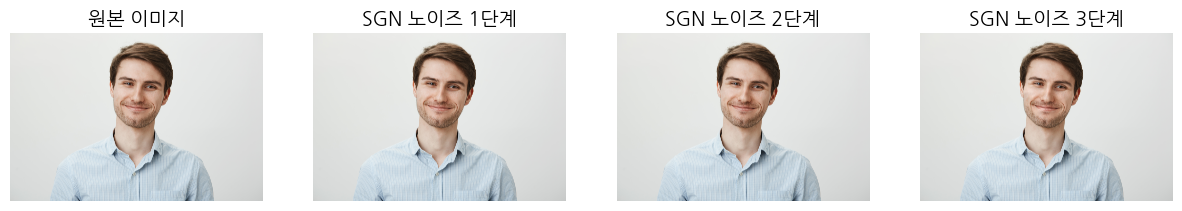

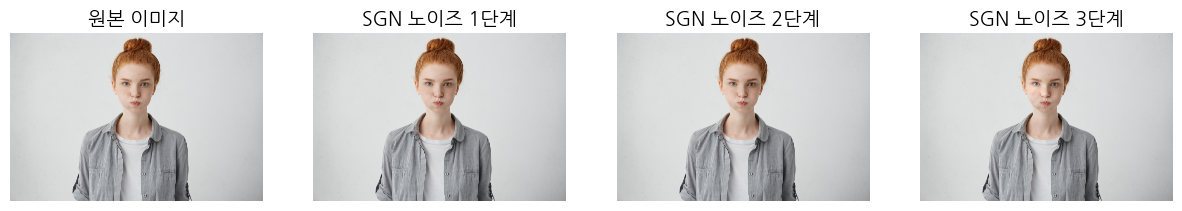

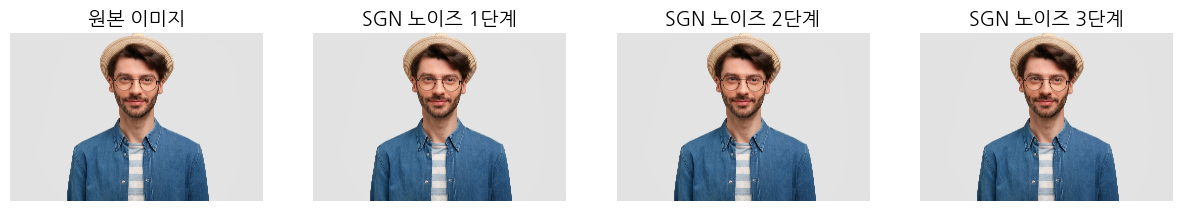

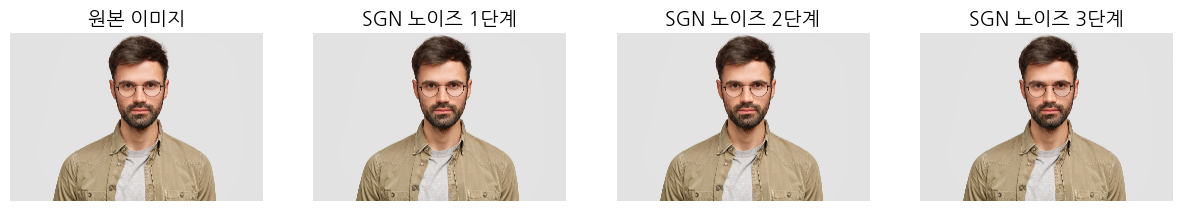

🎉 모든 SGN 보호 이미지 저장 완료!


In [6]:
import os
import glob
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

# 이미지 저장 경로 설정
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

def generate_sgn_noise(image_tensor, strength=0.03):
    """스타일GAN 기반 보호 노이즈 생성"""
    noise_layers = []
    for scale in [4, 8, 16, 32, 64]:
        if scale <= image_tensor.shape[2] and scale <= image_tensor.shape[3]:
            noise = torch.randn(1, 1, scale, scale, device=image_tensor.device)
            upsampled = torch.nn.functional.interpolate(
                noise, size=(image_tensor.shape[2], image_tensor.shape[3]), mode='bilinear', align_corners=False
            )
            noise_layers.append(upsampled)
    
    combined_noise = sum(noise_layers) / len(noise_layers)
    noisy_image = image_tensor + combined_noise.expand_as(image_tensor) * strength
    return torch.clamp(noisy_image, 0, 1)

# Haar Cascade를 이용한 얼굴 검출기 초기화
haar_model_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_model_path)

# OpenCV Facemark LBF 초기화 (opencv-contrib-python 필요)
facemark = cv2.face.createFacemarkLBF()
# lbfmodel.yaml 파일의 경로를 올바르게 지정해주세요.
lbf_model_path = "lbfmodel.yaml"
facemark.loadModel(lbf_model_path)

def get_face_mask(pil_img):
    """
    OpenCV의 얼굴 검출기와 Facemark LBF를 사용하여 얼굴 랜드마크를 추출하고,
    얼굴 윤곽(예: 68개 랜드마크, 인덱스 0~68)에 해당하는 부분의 convex hull을 생성하여 마스크로 만듭니다.
    """
    img_np = np.array(pil_img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    height, width = gray.shape
    mask = np.zeros((height, width), dtype=np.uint8)
    
    # Haar Cascade로 얼굴 검출
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) == 0:
        return mask
    
    # Facemark LBF로 얼굴 랜드마크 추출
    ok, landmarks = facemark.fit(gray, faces)
    if not ok or len(landmarks) == 0:
        return mask
    
    # 첫 번째 얼굴의 랜드마크 사용 (얼굴 전체 영역: 인덱스 0~68)
    for landmark in landmarks:
        face_contour = landmark[0][0:68].astype(np.int32)
        hull = cv2.convexHull(face_contour)
        cv2.fillConvexPoly(mask, hull, 255)
        break  # 첫 얼굴만 처리
    return mask

def protect_face_polygon(image_path, output_base, noise_level, model_name):
    """
    이미지에서 얼굴 윤곽에 해당하는 영역에만 스타일GAN 기반 노이즈를 적용합니다.
    얼굴 검출에 실패하면 전체 이미지에 노이즈를 적용합니다.
    
    ※ 얼굴 윤곽 검출 결과를 오버레이하는 코드는 제거되었습니다.
    """
    img = Image.open(image_path).convert("RGB")
    mask_np = get_face_mask(img)
    
    # 얼굴이 검출되지 않으면 전체 이미지에 노이즈 적용
    if np.sum(mask_np) == 0:
        print("⚠️ 얼굴이 감지되지 않아 전체 이미지에 노이즈를 적용합니다.")
        img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
        noisy_img_tensor = generate_sgn_noise(img_tensor, noise_level)
        result_img = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())
    else:
        # 노이즈 적용 (얼굴 영역만)
        img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
        mask_tensor = torch.from_numpy(mask_np).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
        noisy_img_tensor = generate_sgn_noise(img_tensor, noise_level)
        composite_tensor = img_tensor * (1 - mask_tensor) + noisy_img_tensor * mask_tensor
        result_img = transforms.ToPILImage()(composite_tensor.squeeze(0).cpu())
    
    output_path = f"{output_base}_{model_name}_{int(noise_level*100)}.jpg"
    output_path = os.path.join(output_dir, os.path.basename(output_path))
    result_img.save(output_path)
    return result_img

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, len(protected_list) + 1, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")
    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 노이즈 {i+1}단계", fontsize=14)
        axes[i + 1].axis("off")
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.03, 0.05, 0.1), model_name="SGN"):
    """입력 폴더의 모든 이미지에 대해 얼굴 윤곽에만 스타일GAN 보호 노이즈 적용"""
    if not os.path.exists(input_dir):
        print("⚠️ 입력 폴더가 존재하지 않습니다.")
        return

    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))
    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return

    protected_images_dict = {}
    original_images_dict = {}
    
    with tqdm(total=len(image_paths) * len(noise_levels), desc="이미지 변환 및 저장 진행") as pbar:
        for img_path in image_paths:
            img_name, _ = os.path.splitext(os.path.basename(img_path))
            protected_images = []
            original = Image.open(img_path).convert("RGB")
            original_images_dict[img_name] = original
            for noise_level in noise_levels:
                output_base = os.path.join(output_dir, img_name)
                os.makedirs(os.path.dirname(output_base), exist_ok=True)
                protected_pil = protect_face_polygon(img_path, output_base, noise_level, model_name)
                protected_images.append(protected_pil)
                pbar.update(1)
            protected_images_dict[img_name] = protected_images
    
    print("이미지 출력 중...")
    for img_name, protected_images in protected_images_dict.items():
        display_images(original_images_dict[img_name], protected_images, img_name, model_name)
    print(f"🎉 모든 {model_name} 보호 이미지 저장 완료!")

# 실행
process_images()
